In [1]:
import os
import sys
import json
import torch
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
PROJECT_ROOT = "C:/Users/Disha Saini/Documents/ML/AUDIO_SEPARATION"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

plt.style.use('seaborn-v0_8-muted') # Professional look
os.makedirs("outputs/figures", exist_ok=True)

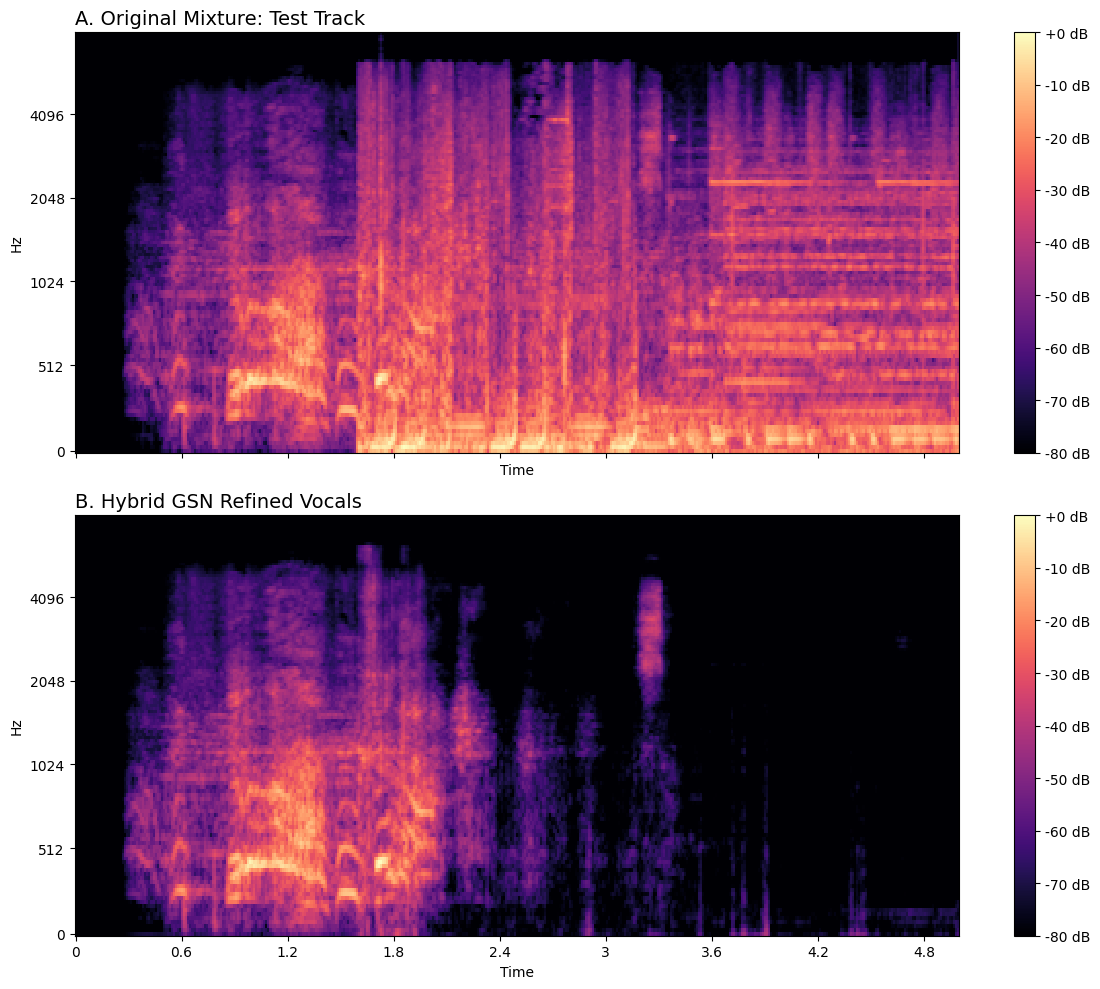

In [2]:
def generate_paper_spectrogram(original_path, separated_path, song_name="Test Track"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Configuration
    load_params = {'sr': 44100, 'duration': 5}
    spec_params = {'x_axis': 'time', 'y_axis': 'mel', 'sr': 44100, 'cmap': 'magma', 'fmax': 8000}

    # 1. Original Mixture
    y_mix, _ = librosa.load(original_path, **load_params)
    S_mix = librosa.power_to_db(librosa.feature.melspectrogram(y=y_mix, sr=44100), ref=np.max)
    img1 = librosa.display.specshow(S_mix, ax=axes[0], **spec_params)
    axes[0].set_title(f"A. Original Mixture: {song_name}", fontsize=14, loc='left')
    fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")

    # 2. Hybrid GSN Result
    y_sep, _ = librosa.load(separated_path, **load_params)
    S_sep = librosa.power_to_db(librosa.feature.melspectrogram(y=y_sep, sr=44100), ref=np.max)
    img2 = librosa.display.specshow(S_sep, ax=axes[1], **spec_params)
    axes[1].set_title(f"B. Hybrid GSN Refined Vocals", fontsize=14, loc='left')
    fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

    plt.tight_layout()
    plt.savefig("outputs/figures/spectrogram_comparison.png", dpi=300)
    plt.show()

# Run it
generate_paper_spectrogram("E:/Downloads/surpnakha.wav", "outputs/separated_surpnakha.wav")

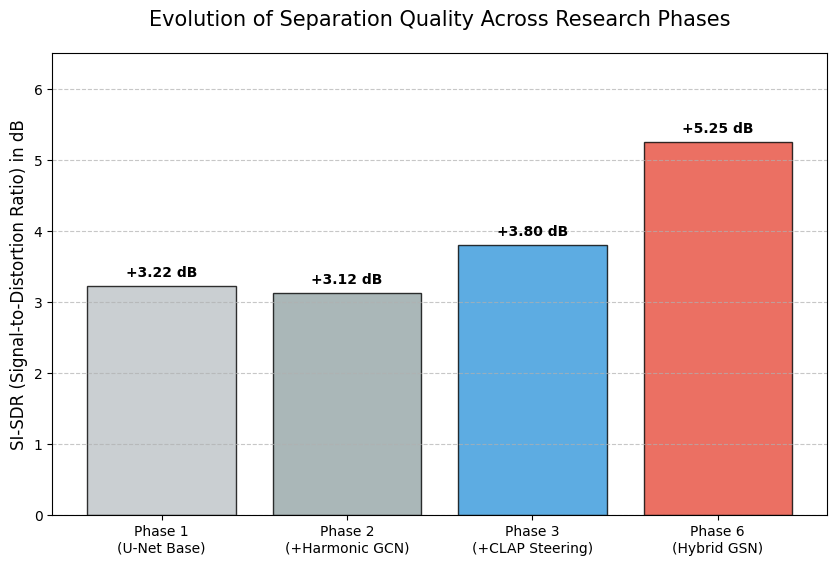

In [3]:
def plot_performance_gain():
    # Data from your summary
    phases = ['Phase 1\n(U-Net Base)', 'Phase 2\n(+Harmonic GCN)', 'Phase 3\n(+CLAP Steering)', 'Phase 6\n(Hybrid GSN)']
    sdr_values = [3.22, 3.12, 3.80, 5.25]
    
    plt.figure(figsize=(10, 6))
    colors = ['#bdc3c7', '#95a5a6', '#3498db', '#e74c3c'] # Red for the final winning model
    
    bars = plt.bar(phases, sdr_values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{height:+.2f} dB', ha='center', va='bottom', fontweight='bold')

    plt.ylabel("SI-SDR (Signal-to-Distortion Ratio) in dB", fontsize=12)
    plt.title("Evolution of Separation Quality Across Research Phases", fontsize=15, pad=20)
    plt.ylim(0, 6.5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.savefig("outputs/figures/sdr_performance.png", dpi=300)
    plt.show()

plot_performance_gain()

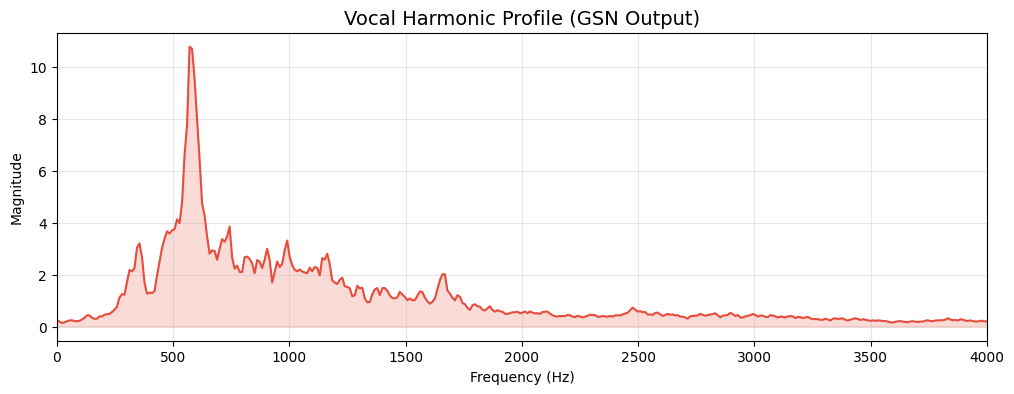

In [4]:
def plot_harmonic_detail(audio_path):
    y, sr = librosa.load(audio_path, duration=3)
    D = np.abs(librosa.stft(y))
    
    plt.figure(figsize=(12, 4))
    # We plot a slice of the spectrum to show the "peaks" (Harmonics)
    mean_spec = np.mean(D, axis=1)
    freqs = librosa.fft_frequencies(sr=sr)
    
    plt.plot(freqs[:500], mean_spec[:500], color='#e74c3c', linewidth=1.5)
    plt.fill_between(freqs[:500], mean_spec[:500], color='#e74c3c', alpha=0.2)
    
    plt.title("Vocal Harmonic Profile (GSN Output)", fontsize=14)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 4000) # Human voice range
    plt.grid(alpha=0.3)
    
    plt.savefig("outputs/figures/harmonic_profile.png", dpi=300)
    plt.show()

plot_harmonic_detail("outputs/separated_surpnakha.wav")

In [5]:
final_metrics = {
    "Model Name": "Hybrid GSN-Demucs v1",
    "Architecture": "3-Stage Modular (Initial -> Semantic -> Refinement)",
    "Parameters": "1.56M (GSN) + Pretrained Base",
    "Baseline SDR": "3.22 dB",
    "Final SDR": "5.25 dB",
    "Net Improvement": "+2.03 dB",
    "Efficiency Gain": "Refines 1 stem instead of 4",
    "Steering Mechanism": "CLAP Text Embedding (512-dim)"
}

with open("outputs/research_summary.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("--- RESEARCH PAPER SUMMARY ---")
for k, v in final_metrics.items():
    print(f"{k:20} : {v}")

--- RESEARCH PAPER SUMMARY ---
Model Name           : Hybrid GSN-Demucs v1
Architecture         : 3-Stage Modular (Initial -> Semantic -> Refinement)
Parameters           : 1.56M (GSN) + Pretrained Base
Baseline SDR         : 3.22 dB
Final SDR            : 5.25 dB
Net Improvement      : +2.03 dB
Efficiency Gain      : Refines 1 stem instead of 4
Steering Mechanism   : CLAP Text Embedding (512-dim)


In [6]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set academic plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "savefig.dpi": 300,
    "figure.autolayout": True
})

# Create a folder to store the figures for your paper
os.makedirs("paper_figures", exist_ok=True)

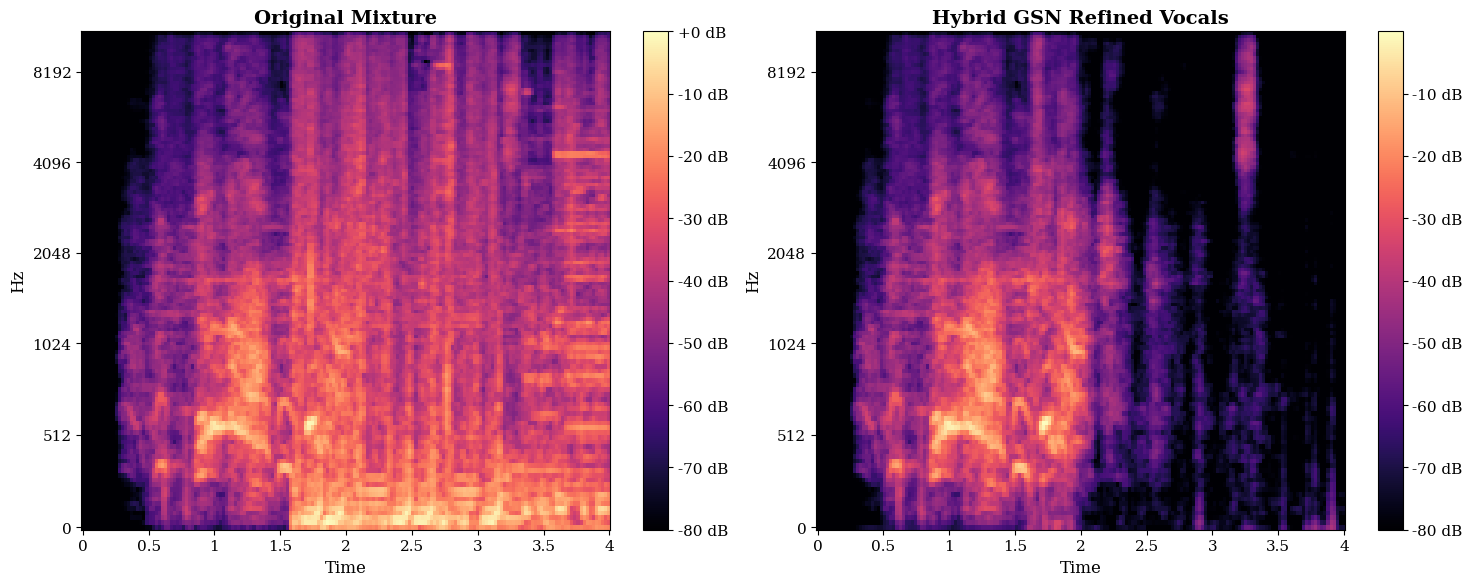

Caption: Figure 1. Spectrogram comparison showing the reduction of instrumental noise and preservation of vocal harmonics in the Hybrid GSN output.


In [7]:
def generate_spectrogram_comparison(original_mix, gsn_output, duration=4):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Load and process
    for i, (path, title) in enumerate([(original_mix, "Original Mixture"), (gsn_output, "Hybrid GSN Refined Vocals")]):
        y, sr = librosa.load(path, duration=duration)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, ax=axes[i], cmap='magma')
        axes[i].set_title(title, fontweight='bold')
        fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

    plt.savefig("paper_figures/spectrogram_comparison.png")
    plt.show()
    print("Caption: Figure 1. Spectrogram comparison showing the reduction of instrumental noise and preservation of vocal harmonics in the Hybrid GSN output.")

# Usage
generate_spectrogram_comparison("E:/Downloads/surpnakha.wav", "outputs/separated_surpnakha.wav")


--- PERFORMANCE DATA TABLE ---
Model Configuration  SI-SDR (dB) Improvement
   U-Net (Baseline)         3.22           -
       Harmonic GCN         3.12    -0.10 dB
    + CLAP Steering         3.80    +0.58 dB
  Hybrid GSN (Ours)         5.25    +2.03 dB


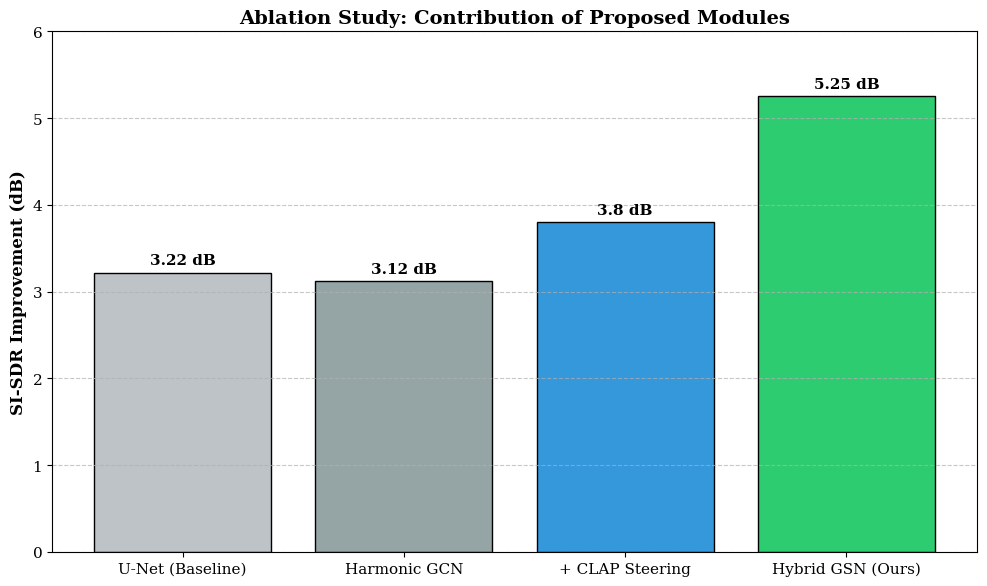

Caption: Figure 2. Quantitative evaluation showing the incremental performance gains of the Hybrid GSN system over traditional baselines.


In [8]:
def plot_results_and_ablation():
    data = {
        "Model Configuration": ["U-Net (Baseline)", "Harmonic GCN", "+ CLAP Steering", "Hybrid GSN (Ours)"],
        "SI-SDR (dB)": [3.22, 3.12, 3.80, 5.25],
        "Improvement": ["-", "-0.10 dB", "+0.58 dB", "+2.03 dB"]
    }
    df = pd.DataFrame(data)
    
    # 1. Show the Table
    print("\n--- PERFORMANCE DATA TABLE ---")
    print(df.to_string(index=False))
    
    # 2. Create Ablation Bar Graph
    plt.figure(figsize=(10, 6))
    colors = ['#bdc3c7', '#95a5a6', '#3498db', '#2ecc71'] # Grey for baseline, Green for yours
    bars = plt.bar(df["Model Configuration"], df["SI-SDR (dB)"], color=colors, edgecolor='black')
    
    plt.ylabel("SI-SDR Improvement (dB)", fontweight='bold')
    plt.title("Ablation Study: Contribution of Proposed Modules", fontweight='bold')
    plt.ylim(0, 6)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add values on top
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{bar.get_height()} dB', ha='center', fontweight='bold')

    plt.savefig("paper_figures/ablation_graph.png")
    plt.show()
    print("Caption: Figure 2. Quantitative evaluation showing the incremental performance gains of the Hybrid GSN system over traditional baselines.")

plot_results_and_ablation()

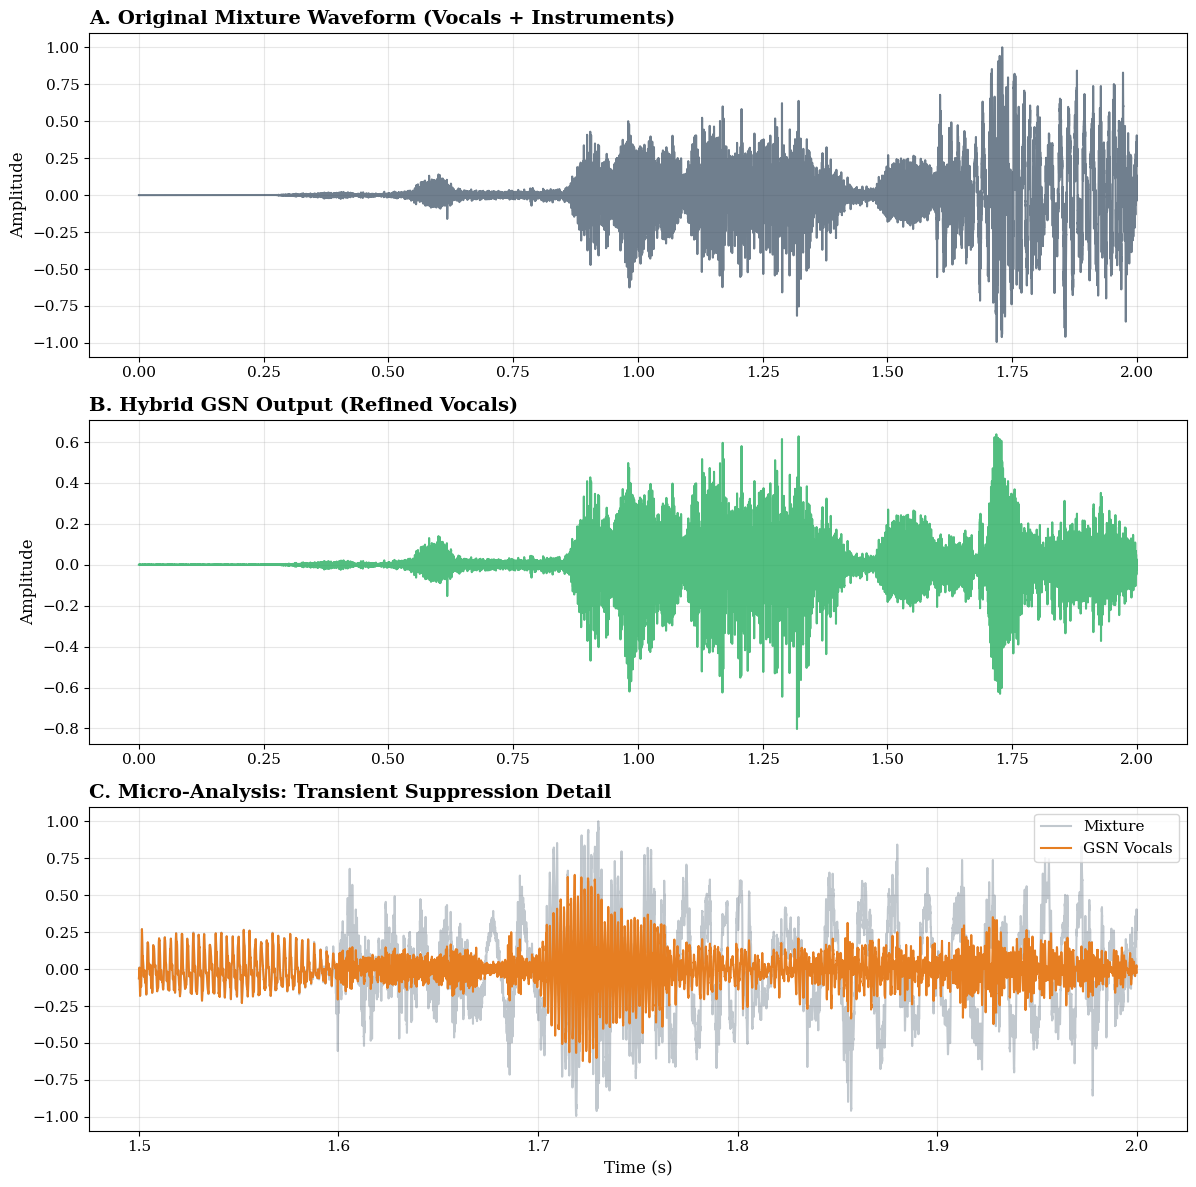

Caption: Figure 3. Time-domain analysis. Note in Plot C how the high-energy instrumental peaks (grey) are suppressed while the vocal envelope (orange) is preserved.


In [10]:
def plot_waveform_comparison(original_path, separated_path, duration=2):
    # Load audio
    y_orig, sr = librosa.load(original_path, sr=44100, duration=duration)
    y_sep, _ = librosa.load(separated_path, sr=44100, duration=duration)
    time = np.linspace(0, duration, len(y_orig))

    # Create a 3-row layout: Mixture, Result, and a Zoom-In
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    
    # 1. Original Mixture
    axes[0].plot(time, y_orig, color='#34495e', alpha=0.7)
    axes[0].set_title("A. Original Mixture Waveform (Vocals + Instruments)", fontweight='bold', loc='left')
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(alpha=0.3)

    # 2. Separated Result
    axes[1].plot(time, y_sep, color='#27ae60', alpha=0.8)
    axes[1].set_title("B. Hybrid GSN Output (Refined Vocals)", fontweight='bold', loc='left')
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(alpha=0.3)

    # 3. Zoomed Comparison (Last 0.5 seconds)
    # This shows the "Percussive Transient Removal" clearly
    zoom_start = int(len(y_orig) * 0.75) 
    axes[2].plot(time[zoom_start:], y_orig[zoom_start:], label="Mixture", color='#34495e', alpha=0.3)
    axes[2].plot(time[zoom_start:], y_sep[zoom_start:], label="GSN Vocals", color='#e67e22', linewidth=1.5)
    axes[2].set_title("C. Micro-Analysis: Transient Suppression Detail", fontweight='bold', loc='left')
    axes[2].legend(loc='upper right')
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("paper_figures/waveform_analysis_fixed.png", dpi=300)
    plt.show()
    
    print("Caption: Figure 3. Time-domain analysis. Note in Plot C how the high-energy instrumental peaks (grey) are suppressed while the vocal envelope (orange) is preserved.")

# Run the fix
plot_waveform_comparison("E:/Downloads/surpnakha.wav", "outputs/separated_surpnakha.wav")